In [1]:
import numpy as np
import umap
import matplotlib.pyplot as plt

In [3]:
real_path = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_cnn_metrics_14_04_best_model_val_acc.npy"
synt_path = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_val_best_model_val_acc.npy"

In [4]:
def get_umap(path: str) -> np.ndarray:
    X_latent = np.load(path, allow_pickle=True)
    print(type(X_latent), X_latent.shape)
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="cosine",
        # random_state=42,
    )

    X_umap = reducer.fit_transform(X_latent)
    return X_umap

In [5]:
real_umap = get_umap(real_path)
synt_umap = get_umap(synt_path)

<class 'numpy.ndarray'> (472, 512)
<class 'numpy.ndarray'> (221110, 512)


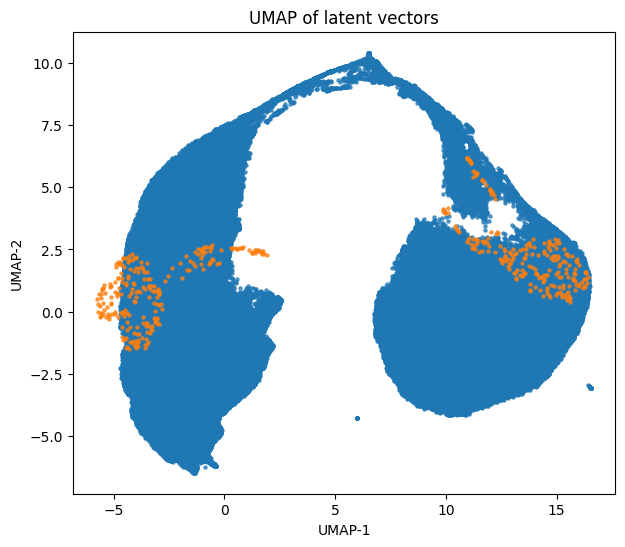

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(synt_umap[:, 0], synt_umap[:, 1], s=5, alpha=0.7)
plt.scatter(real_umap[:, 0], real_umap[:, 1], s=5, alpha=0.7)
plt.title("UMAP of latent vectors")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()